# FNSPID trend-volatility base with a frozen sentiment brake

**Status:** iterative evaluation analysis, specification frozen on 2026-08-05
before this notebook was executed. The 2020-2023 block was already opened by
earlier final-experiment notebooks, so this is not a new confirmatory test.

The question is deliberately base-first: can a standard market-risk policy
provide a more useful return engine, and does the already-frozen aggregate
news rule add anything incremental to it?

The linked `sentiment-trading-llm` replication contributes validity controls
(dense calendar, chronological split, exact turnover, inactive cash), not a
positive strategy: its corrected costed sentiment portfolios are null.

## Frozen design

- **Asset / return:** SPY adjusted-open to next adjusted-open, cash return 0.
- **Trend:** price above its 200-session moving average, formed with a full
  one-session lag; risk-off means cash. No moving-average sweep.
- **Volatility base:** Notebook 21's sentiment-free HAR forecast, 10% annual
  target, exposure clipped to [0.25, 1.00]. No refit here.
- **Sentiment modifier:** Notebook 20's unchanged hysteresis rule: enter
  risk-off at aggregate negative-pressure z >= 1.5, exit at z <= 0.5, and use
  a 0.25 exposure multiplier while risk-off.
- **Arms:** long SPY, trend only, HAR only, trend x HAR, and
  trend x HAR x sentiment.
- **Costs:** 2 bps per side, with entry, changes, and final liquidation; cost
  curve at 0, 1, 2, 5, and 10 bps.
- **Inference:** paired 20-session circular blocks, 4,999 replications.

Primary incremental estimands are (1) trend x HAR minus HAR and (2) sentiment
overlay minus trend x HAR. A useful base requires Sharpe improvement >= 0.10,
relative drawdown reduction >= 20%, and a paired net-return CI lower bound no
worse than -1 bp/day. The sentiment layer requires Sharpe improvement >= 0.10,
drawdown reduction >= 10%, the same return non-inferiority bound, and
non-negative mean differences in both 2020 and 2021-2023. These are diagnostic
gates, not claims of fresh out-of-sample discovery.

In [1]:
from __future__ import annotations

import hashlib
import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.panel import (  # noqa: E402
    DEFAULT_PRICE_ZIP,
    load_adjusted_open_prices,
)
from final_experiments.lib.plots import (  # noqa: E402
    CATEGORICAL,
    INK,
    STATUS,
    apply_house_style,
)
from final_experiments.lib.risk_overlay import (  # noqa: E402
    MomentumOverlayConfig,
    build_adjusted_open_returns,
    reprice_daily,
    summarize_weight_backtest,
)
from final_experiments.lib.volatility_target import (  # noqa: E402
    backtest_single_asset_exposure,
    build_lagged_price_trend,
    multiply_exposures,
    paired_circular_block_mean,
)

apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

OUTPUT_DIR = REPO_ROOT / "final_experiments" / "outputs" / "23_fnspid_trend_volatility_sentiment_base"
HAR_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "21_fnspid_sentiment_volatility_target"
    / "evaluation_control_har_target_daily.parquet"
)
SENTIMENT_PATH = (
    REPO_ROOT
    / "final_experiments"
    / "outputs"
    / "20_fnspid_market_sentiment_risk_overlay"
    / "evaluation_hysteresis_daily.parquet"
)
TREND_LOOKBACK = 200
COST_BPS = 2.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 20
REPLICATIONS = 4_999
SEED = 20260805
ARMS = (
    "long_spy",
    "trend_200",
    "control_har_target",
    "trend_200_har",
    "trend_200_har_sentiment",
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"repo:   {REPO_ROOT}")
print(f"output: {OUTPUT_DIR}")

repo:   /Users/peterprendergast/Documents/Sentiment_Dissertation
output: /Users/peterprendergast/Documents/Sentiment_Dissertation/final_experiments/outputs/23_fnspid_trend_volatility_sentiment_base


## Load independent price history and frozen component paths

Only SPY prices and aggregate exposure paths are loaded; no licensed headline
text is read. The full price history supplies a clean 200-session trend warm-up.

In [2]:
for required_path in (DEFAULT_PRICE_ZIP, HAR_PATH, SENTIMENT_PATH):
    if not required_path.exists():
        raise FileNotFoundError(required_path)

prices, missing_symbols = load_adjusted_open_prices(DEFAULT_PRICE_ZIP, {"SPY"})
if missing_symbols:
    raise RuntimeError(f"SPY price history missing: {missing_symbols}")
spy_returns = build_adjusted_open_returns(
    prices,
    symbol="SPY",
    return_col="forward_return",
)
har_daily = pd.read_parquet(HAR_PATH)
sentiment_daily = pd.read_parquet(SENTIMENT_PATH)
for frame in (spy_returns, har_daily, sentiment_daily):
    frame["session_date"] = pd.to_datetime(frame["session_date"]).dt.normalize()

def sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

input_audit = pd.DataFrame(
    [
        {
            "full_spy_return_rows": len(spy_returns),
            "full_spy_start": spy_returns["session_date"].min(),
            "full_spy_end": spy_returns["session_date"].max(),
            "evaluation_sessions": len(har_daily),
            "evaluation_start": har_daily["session_date"].min(),
            "evaluation_end": har_daily["session_date"].max(),
            "sentiment_sessions": len(sentiment_daily),
            "price_zip_bytes": DEFAULT_PRICE_ZIP.stat().st_size,
            "har_sha256": sha256(HAR_PATH),
            "sentiment_sha256": sha256(SENTIMENT_PATH),
        }
    ]
)
display(input_audit)

,full_spy_return_rows,full_spy_start,full_spy_end,evaluation_sessions,evaluation_start,evaluation_end,sentiment_sessions,price_zip_bytes,har_sha256,sentiment_sha256
0,3268,2011-01-03,2023-12-27,998,2020-01-02,2023-12-18,998,589525596,2b8207b56c542cb422593e2be7fdb9380ba136ae2bc09c...,fa4c90b6a51f77560bb36ec0d3cd9abba72e9f769afd78...


## Build and audit the lagged trend signal

In [3]:
trend_full = build_lagged_price_trend(
    spy_returns,
    lookback=TREND_LOOKBACK,
    return_col="forward_return",
)
evaluation_dates = har_daily[["session_date"]].drop_duplicates()
trend_eval = evaluation_dates.merge(trend_full, on="session_date", how="left", validate="1:1")
if trend_eval["exposure"].isna().any():
    raise RuntimeError("trend warm-up does not cover every evaluation session")

return_check = har_daily[["session_date", "forward_return"]].merge(
    spy_returns[["session_date", "forward_return"]].rename(
        columns={"forward_return": "price_source_return"}
    ),
    on="session_date",
    how="left",
    validate="1:1",
)
return_check["absolute_difference"] = (
    return_check["forward_return"] - return_check["price_source_return"]
).abs()
max_return_difference = float(return_check["absolute_difference"].max())
assert max_return_difference < 1e-12

trend_audit = pd.DataFrame(
    [
        {
            "lookback_sessions": TREND_LOOKBACK,
            "first_complete_full_history_signal": trend_full.loc[
                trend_full["exposure"].notna(), "session_date"
            ].min(),
            "evaluation_risk_on_sessions": int(trend_eval["exposure"].eq(1).sum()),
            "evaluation_cash_sessions": int(trend_eval["exposure"].eq(0).sum()),
            "evaluation_risk_on_share": trend_eval["exposure"].mean(),
            "max_return_source_difference": max_return_difference,
        }
    ]
)
display(trend_audit)

,lookback_sessions,first_complete_full_history_signal,evaluation_risk_on_sessions,evaluation_cash_sessions,evaluation_risk_on_share,max_return_source_difference
0,200,2011-10-18,716,282,0.717435,0.000000


## Compose the five predeclared exposure paths

In [4]:
returns_eval = har_daily[["session_date", "forward_return"]].copy()
long_exposure = evaluation_dates.assign(arm="long_spy", exposure=1.0)
trend_exposure = trend_eval[["session_date", "exposure"]].assign(arm="trend_200")
har_exposure = har_daily[["session_date", "exposure"]].assign(arm="control_har_target")
trend_har_exposure = multiply_exposures(
    har_exposure,
    trend_exposure,
    arm="trend_200_har",
)
sentiment_exposure = sentiment_daily[["session_date", "gross_exposure"]].rename(
    columns={"gross_exposure": "exposure"}
)
trend_har_sentiment_exposure = multiply_exposures(
    trend_har_exposure[["session_date", "exposure"]],
    sentiment_exposure,
    arm="trend_200_har_sentiment",
)

exposures = {
    "long_spy": long_exposure,
    "trend_200": trend_exposure,
    "control_har_target": har_exposure,
    "trend_200_har": trend_har_exposure,
    "trend_200_har_sentiment": trend_har_sentiment_exposure,
}
exposure_summary = pd.DataFrame(
    [
        {
            "arm": arm,
            "n_sessions": len(path),
            "mean_exposure": path["exposure"].mean(),
            "cash_share": path["exposure"].eq(0).mean(),
            "full_exposure_share": path["exposure"].eq(1).mean(),
            "minimum_exposure": path["exposure"].min(),
            "maximum_exposure": path["exposure"].max(),
        }
        for arm, path in exposures.items()
    ]
)
display(exposure_summary)

,arm,n_sessions,mean_exposure,cash_share,full_exposure_share,minimum_exposure,maximum_exposure
0,long_spy,998,1.000000,0.000000,1.000000,1.000000,1.000000
1,trend_200,998,0.717435,0.282565,0.717435,0.000000,1.000000
2,control_har_target,998,0.618573,0.000000,0.040080,0.250000,1.000000
3,trend_200_har,998,0.495234,0.282565,0.040080,0.000000,1.000000
4,trend_200_har_sentiment,998,0.465969,0.282565,0.035070,0.000000,1.000000


## Backtest with common returns and accounting

In [5]:
summary_config = MomentumOverlayConfig(
    cost_bps_per_side=COST_BPS,
    bootstrap_block_length=BLOCK_LENGTH,
    bootstrap_replications=REPLICATIONS,
    random_seed=SEED,
)
daily_paths: dict[str, pd.DataFrame] = {}
result_rows = []
for arm, exposure in exposures.items():
    daily = backtest_single_asset_exposure(
        returns_eval,
        exposure[["session_date", "exposure"]],
        cost_bps_per_side=COST_BPS,
    )
    daily["arm"] = arm
    daily["downside_sq"] = daily["net_return"].clip(upper=0).pow(2)
    daily_paths[arm] = daily
    result_rows.append({"arm": arm, **summarize_weight_backtest(daily, config=summary_config)})

results = pd.DataFrame(result_rows).set_index("arm").loc[list(ARMS)].reset_index()
display(
    results[
        [
            "arm",
            "sharpe_gross",
            "sharpe_net",
            "total_return_net",
            "ann_vol_net",
            "max_drawdown",
            "mean_gross_exposure",
            "annualized_turnover",
            "breakeven_bps_per_side",
        ]
    ]
)

,arm,sharpe_gross,sharpe_net,total_return_net,ann_vol_net,max_drawdown,mean_gross_exposure,annualized_turnover,breakeven_bps_per_side
0,long_spy,0.568328,0.567850,0.474961,0.213043,-0.320490,1.000000,0.252505,"2,397.529805"
1,trend_200,0.308116,0.294121,0.135176,0.144501,-0.287589,0.717435,5.050100,44.079149
2,control_har_target,0.693755,0.672674,0.298474,0.106498,-0.157300,0.618573,5.615735,65.783753
3,trend_200_har,0.461794,0.430996,0.141942,0.086453,-0.176082,0.495234,6.651597,30.008986
4,trend_200_har_sentiment,0.725553,0.677260,0.223877,0.080067,-0.176454,0.465969,9.655990,30.078969


## Paired incremental inference and matched-exposure attribution

In [6]:
def paired_estimand(
    challenger: str,
    baseline: str,
    *,
    kind: str,
    seed: int,
) -> dict[str, float | int | str]:
    left = daily_paths[challenger].set_index("session_date")
    right = daily_paths[baseline].set_index("session_date")
    common = left.index.intersection(right.index).sort_values()
    if kind == "net_return":
        values = left.loc[common, "net_return"] - right.loc[common, "net_return"]
        estimand = f"{challenger} minus {baseline} net return"
    elif kind == "downside_improvement":
        values = right.loc[common, "downside_sq"] - left.loc[common, "downside_sq"]
        estimand = f"{baseline} minus {challenger} downside squared return"
    else:
        raise ValueError(kind)
    inference = paired_circular_block_mean(
        values,
        block_length=BLOCK_LENGTH,
        replications=REPLICATIONS,
        seed=seed,
    )
    return {"comparison": f"{challenger}_vs_{baseline}", "estimand": estimand, **inference}

inference_rows = [
    paired_estimand("trend_200_har", "control_har_target", kind="net_return", seed=SEED + 1),
    paired_estimand(
        "trend_200_har",
        "control_har_target",
        kind="downside_improvement",
        seed=SEED + 2,
    ),
    paired_estimand(
        "trend_200_har_sentiment",
        "trend_200_har",
        kind="net_return",
        seed=SEED + 3,
    ),
    paired_estimand(
        "trend_200_har_sentiment",
        "trend_200_har",
        kind="downside_improvement",
        seed=SEED + 4,
    ),
]
paired_inference = pd.DataFrame(inference_rows)
display(paired_inference)

base_mean_exposure = float(trend_har_exposure["exposure"].mean())
overlay_mean_exposure = float(trend_har_sentiment_exposure["exposure"].mean())
constant_scale = overlay_mean_exposure / base_mean_exposure
matched_exposure = trend_har_exposure[["session_date", "exposure"]].copy()
matched_exposure["exposure"] *= constant_scale
matched_daily = backtest_single_asset_exposure(
    returns_eval,
    matched_exposure,
    cost_bps_per_side=COST_BPS,
)
matched_daily["downside_sq"] = matched_daily["net_return"].clip(upper=0).pow(2)
matched_summary = summarize_weight_backtest(matched_daily, config=summary_config)
overlay_summary = results.set_index("arm").loc["trend_200_har_sentiment"]
matched_diff = paired_circular_block_mean(
    daily_paths["trend_200_har_sentiment"]["net_return"] - matched_daily["net_return"],
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED + 5,
)
matched_attribution = pd.DataFrame(
    [
        {
            "overlay_mean_exposure": overlay_mean_exposure,
            "constant_scale": constant_scale,
            "overlay_sharpe": overlay_summary["sharpe_net"],
            "matched_constant_sharpe": matched_summary["sharpe_net"],
            "overlay_minus_constant_bps_day": 10_000 * matched_diff["mean"],
            "ci_low_bps_day": 10_000 * matched_diff["ci_low"],
            "ci_high_bps_day": 10_000 * matched_diff["ci_high"],
            "p_two_sided": matched_diff["p_two_sided"],
        }
    ]
)
display(matched_attribution)

,comparison,estimand,n,mean,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,trend_200_har_vs_control_har_target,trend_200_har minus control_har_target net return,998,-0.000136,-0.000350,0.000075,0.200600,20,4999,20260806
1,trend_200_har_vs_control_har_target,control_har_target minus trend_200_har downsid...,998,0.000008,0.000004,0.000012,0.000800,20,4999,20260807
2,trend_200_har_sentiment_vs_trend_200_har,trend_200_har_sentiment minus trend_200_har ne...,998,0.000067,-0.000032,0.000189,0.226000,20,4999,20260808
3,trend_200_har_sentiment_vs_trend_200_har,trend_200_har minus trend_200_har_sentiment do...,998,0.000003,0.000001,0.000006,0.015000,20,4999,20260809


,overlay_mean_exposure,constant_scale,overlay_sharpe,matched_constant_sharpe,overlay_minus_constant_bps_day,ci_low_bps_day,ci_high_bps_day,p_two_sided
0,0.465969,0.940908,0.677260,0.430996,0.760595,-0.211441,1.867794,0.147400


## Temporal stability and cost sensitivity

In [7]:
def period_summary(arm: str, label: str, start: str, end: str) -> dict[str, float | int | str]:
    daily = daily_paths[arm]
    mask = daily["session_date"].between(pd.Timestamp(start), pd.Timestamp(end))
    subset = daily.loc[mask].copy()
    summary = summarize_weight_backtest(subset, config=summary_config)
    return {
        "period": label,
        "arm": arm,
        "n_sessions": summary["n_sessions"],
        "mean_net": summary["mean_net"],
        "sharpe_net": summary["sharpe_net"],
        "total_return_net": summary["total_return_net"],
        "max_drawdown": summary["max_drawdown"],
    }

periods = (
    ("2020", "2020-01-01", "2020-12-31"),
    ("2021_2023", "2021-01-01", "2023-12-31"),
)
temporal = pd.DataFrame(
    [period_summary(arm, label, start, end) for label, start, end in periods for arm in ARMS]
)
display(temporal)

stability_rows = []
for label, _, _ in periods:
    part = temporal.loc[temporal["period"].eq(label)].set_index("arm")
    stability_rows.extend(
        [
            {
                "period": label,
                "comparison": "trend_200_har_vs_control_har_target",
                "challenger_minus_baseline_bps_day": 10_000
                * (part.loc["trend_200_har", "mean_net"] - part.loc["control_har_target", "mean_net"]),
                "challenger_minus_baseline_sharpe": part.loc["trend_200_har", "sharpe_net"]
                - part.loc["control_har_target", "sharpe_net"],
            },
            {
                "period": label,
                "comparison": "trend_200_har_sentiment_vs_trend_200_har",
                "challenger_minus_baseline_bps_day": 10_000
                * (
                    part.loc["trend_200_har_sentiment", "mean_net"]
                    - part.loc["trend_200_har", "mean_net"]
                ),
                "challenger_minus_baseline_sharpe": part.loc[
                    "trend_200_har_sentiment", "sharpe_net"
                ]
                - part.loc["trend_200_har", "sharpe_net"],
            },
        ]
    )
stability = pd.DataFrame(stability_rows)
display(stability)

cost_rows = []
for arm in ARMS:
    for cost in COST_GRID:
        repriced = reprice_daily(daily_paths[arm], cost_bps_per_side=cost)
        config = MomentumOverlayConfig(
            cost_bps_per_side=cost,
            bootstrap_block_length=BLOCK_LENGTH,
            bootstrap_replications=999,
            random_seed=SEED,
        )
        summary = summarize_weight_backtest(repriced, config=config)
        cost_rows.append(
            {
                "arm": arm,
                "cost_bps_per_side": cost,
                "sharpe_net": summary["sharpe_net"],
                "total_return_net": summary["total_return_net"],
                "max_drawdown": summary["max_drawdown"],
            }
        )
cost_curve = pd.DataFrame(cost_rows)
display(cost_curve)

,period,arm,n_sessions,mean_net,sharpe_net,total_return_net,max_drawdown
0,2020,long_spy,253,0.000628,0.531917,0.120822,-0.320490
1,2020,trend_200,253,0.000201,0.242659,0.029310,-0.217456
2,2020,control_har_target,253,0.000284,0.597468,0.066817,-0.129468
3,2020,trend_200_har,253,0.000167,0.407644,0.037491,-0.099798
4,2020,trend_200_har_sentiment,253,0.000396,1.055474,0.100386,-0.063460
5,2021_2023,long_spy,745,0.000430,0.616953,0.315963,-0.262858
6,2021_2023,trend_200,745,0.000158,0.345257,0.102852,-0.287589
7,2021_2023,control_har_target,745,0.000284,0.704857,0.217148,-0.157300
8,2021_2023,trend_200_har,745,0.000142,0.444884,0.100677,-0.176082
9,2021_2023,trend_200_har_sentiment,745,0.000154,0.519786,0.112225,-0.176454


,period,comparison,challenger_minus_baseline_bps_day,challenger_minus_baseline_sharpe
0,2020,trend_200_har_vs_control_har_target,-1.176807,-0.189824
1,2020,trend_200_har_sentiment_vs_trend_200_har,2.293763,0.647829
2,2021_2023,trend_200_har_vs_control_har_target,-1.427827,-0.259973
3,2021_2023,trend_200_har_sentiment_vs_trend_200_har,0.122888,0.074903


,arm,cost_bps_per_side,sharpe_net,total_return_net,max_drawdown
0,long_spy,0.000000,0.568328,0.475552,-0.320490
1,long_spy,1.000000,0.568089,0.475257,-0.320490
2,long_spy,2.000000,0.567850,0.474961,-0.320490
3,long_spy,5.000000,0.567134,0.474074,-0.320490
4,long_spy,10.000000,0.565938,0.472597,-0.320490
5,trend_200,0.000000,0.308116,0.144298,-0.284725
6,trend_200,1.000000,0.301119,0.139728,-0.286159
7,trend_200,2.000000,0.294121,0.135176,-0.287589
8,trend_200,5.000000,0.273122,0.121626,-0.291866
9,trend_200,10.000000,0.238112,0.099392,-0.298939


## Apply the frozen diagnostic gates

In [8]:
result_index = results.set_index("arm")
base_net_inference = paired_inference.loc[
    (paired_inference["comparison"] == "trend_200_har_vs_control_har_target")
    & paired_inference["estimand"].str.contains("net return")
].iloc[0]
overlay_net_inference = paired_inference.loc[
    (paired_inference["comparison"] == "trend_200_har_sentiment_vs_trend_200_har")
    & paired_inference["estimand"].str.contains("net return")
].iloc[0]

base_sharpe_delta = float(
    result_index.loc["trend_200_har", "sharpe_net"]
    - result_index.loc["control_har_target", "sharpe_net"]
)
base_drawdown_improvement = float(
    1
    - abs(result_index.loc["trend_200_har", "max_drawdown"])
    / abs(result_index.loc["control_har_target", "max_drawdown"])
)
overlay_sharpe_delta = float(
    result_index.loc["trend_200_har_sentiment", "sharpe_net"]
    - result_index.loc["trend_200_har", "sharpe_net"]
)
overlay_drawdown_improvement = float(
    1
    - abs(result_index.loc["trend_200_har_sentiment", "max_drawdown"])
    / abs(result_index.loc["trend_200_har", "max_drawdown"])
)
base_stable = bool(
    stability.loc[
        stability["comparison"].eq("trend_200_har_vs_control_har_target"),
        "challenger_minus_baseline_bps_day",
    ].ge(0).all()
)
overlay_stable = bool(
    stability.loc[
        stability["comparison"].eq("trend_200_har_sentiment_vs_trend_200_har"),
        "challenger_minus_baseline_bps_day",
    ].ge(0).all()
)
gates = {
    "base_sharpe_delta": base_sharpe_delta,
    "base_drawdown_relative_improvement": base_drawdown_improvement,
    "base_paired_net_ci_low_bps_day": 10_000 * float(base_net_inference["ci_low"]),
    "base_stable_nonnegative_mean_both_periods": base_stable,
    "useful_base_gate": bool(
        base_sharpe_delta >= 0.10
        and base_drawdown_improvement >= 0.20
        and 10_000 * float(base_net_inference["ci_low"]) >= -1.0
    ),
    "sentiment_sharpe_delta": overlay_sharpe_delta,
    "sentiment_drawdown_relative_improvement": overlay_drawdown_improvement,
    "sentiment_paired_net_ci_low_bps_day": 10_000 * float(overlay_net_inference["ci_low"]),
    "sentiment_stable_nonnegative_mean_both_periods": overlay_stable,
    "useful_sentiment_gate": bool(
        overlay_sharpe_delta >= 0.10
        and overlay_drawdown_improvement >= 0.10
        and 10_000 * float(overlay_net_inference["ci_low"]) >= -1.0
        and overlay_stable
    ),
}
display(pd.DataFrame([gates]))

,base_sharpe_delta,base_drawdown_relative_improvement,base_paired_net_ci_low_bps_day,base_stable_nonnegative_mean_both_periods,useful_base_gate,sentiment_sharpe_delta,sentiment_drawdown_relative_improvement,sentiment_paired_net_ci_low_bps_day,sentiment_stable_nonnegative_mean_both_periods,useful_sentiment_gate
0,-0.241679,-0.119404,-3.501070,False,False,0.246264,-0.002110,-0.321005,True,False


## Figures

findfont: Failed to find font weight medium, now using 400.


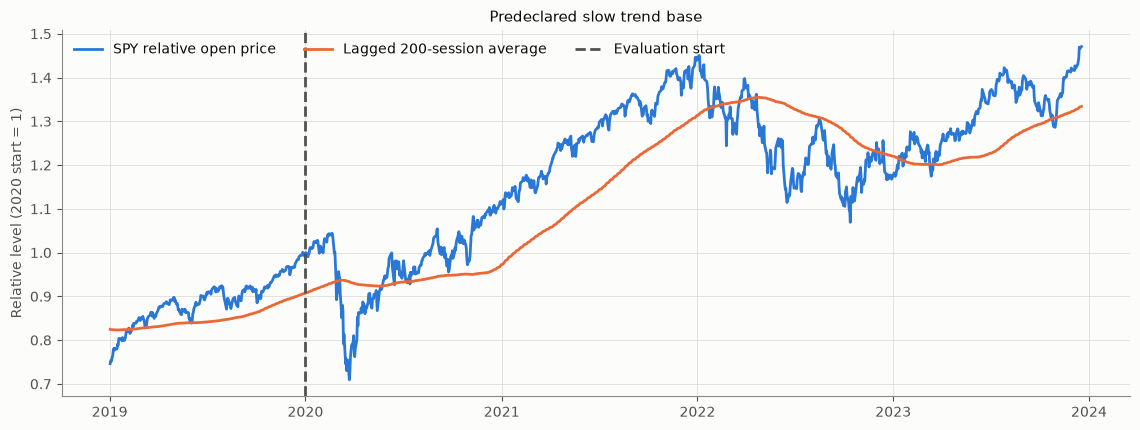

In [9]:
plot_trend = trend_full.loc[
    trend_full["session_date"].between(pd.Timestamp("2019-01-01"), evaluation_dates["session_date"].max())
].copy()
normalizer = float(
    plot_trend.loc[plot_trend["session_date"].ge(pd.Timestamp("2020-01-01")), "relative_price"].iloc[0]
)
fig, ax = plt.subplots(figsize=(11.5, 4.4))
ax.plot(
    plot_trend["session_date"],
    plot_trend["relative_price"] / normalizer,
    label="SPY relative open price",
    color=CATEGORICAL[0],
)
ax.plot(
    plot_trend["session_date"],
    plot_trend["formation_average"] / normalizer,
    label="Lagged 200-session average",
    color=CATEGORICAL[1],
)
ax.axvline(pd.Timestamp("2020-01-01"), color=INK["reference"], linestyle="--", label="Evaluation start")
ax.set_ylabel("Relative level (2020 start = 1)")
ax.set_title("Predeclared slow trend base")
ax.legend(loc="upper left", ncols=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "trend_signal.png", dpi=170, bbox_inches="tight")
plt.show()

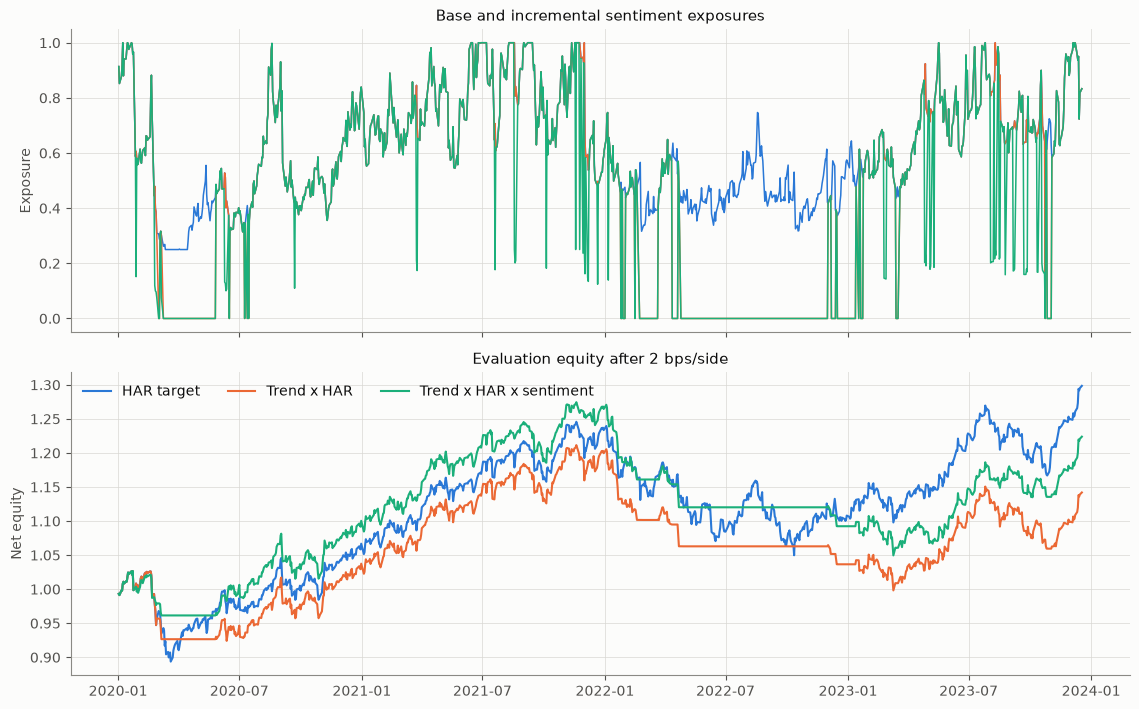

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.2), sharex=True)
for arm, label, color in (
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("trend_200_har", "Trend x HAR", CATEGORICAL[1]),
    ("trend_200_har_sentiment", "Trend x HAR x sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    axes[0].plot(daily["session_date"], daily["gross_exposure"], label=label, color=color, linewidth=1.1)
    axes[1].plot(
        daily["session_date"],
        (1 + daily["net_return"]).cumprod(),
        label=label,
        color=color,
        linewidth=1.5,
    )
axes[0].set_ylabel("Exposure")
axes[0].set_title("Base and incremental sentiment exposures")
axes[1].set_ylabel("Net equity")
axes[1].set_title("Evaluation equity after 2 bps/side")
axes[1].legend(loc="upper left", ncols=3)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "exposure_and_equity.png", dpi=170, bbox_inches="tight")
plt.show()

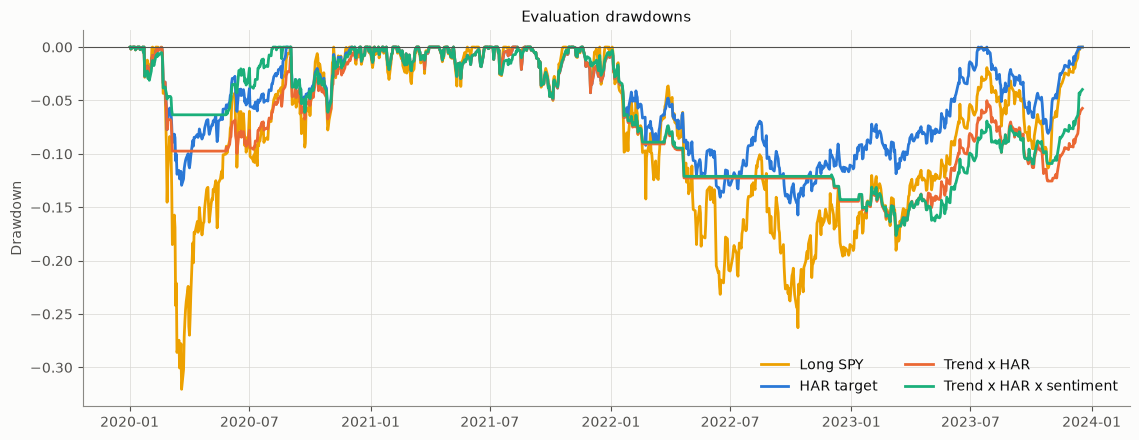

In [11]:
fig, ax = plt.subplots(figsize=(11.5, 4.5))
for arm, label, color in (
    ("long_spy", "Long SPY", CATEGORICAL[3]),
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("trend_200_har", "Trend x HAR", CATEGORICAL[1]),
    ("trend_200_har_sentiment", "Trend x HAR x sentiment", CATEGORICAL[2]),
):
    daily = daily_paths[arm]
    equity = (1 + daily["net_return"]).cumprod()
    drawdown = equity / equity.cummax() - 1
    ax.plot(daily["session_date"], drawdown, label=label, color=color)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_ylabel("Drawdown")
ax.set_title("Evaluation drawdowns")
ax.legend(loc="lower right", ncols=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

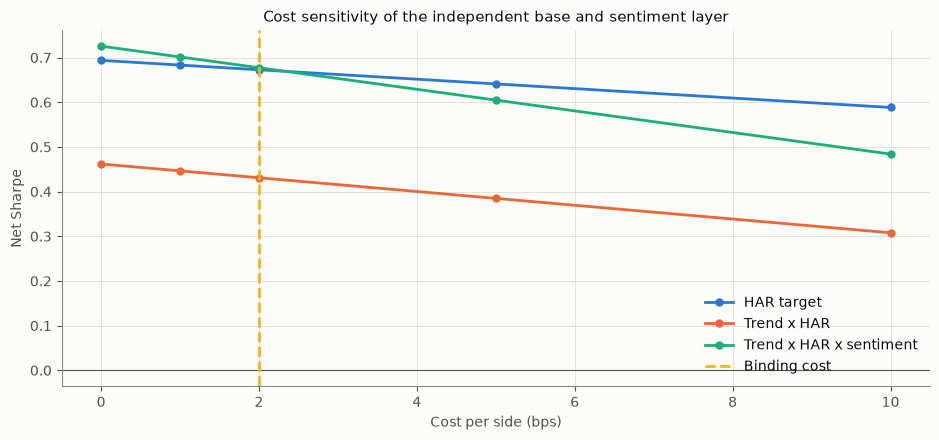

In [12]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
for arm, label, color in (
    ("control_har_target", "HAR target", CATEGORICAL[0]),
    ("trend_200_har", "Trend x HAR", CATEGORICAL[1]),
    ("trend_200_har_sentiment", "Trend x HAR x sentiment", CATEGORICAL[2]),
):
    group = cost_curve.loc[cost_curve["arm"].eq(arm)]
    ax.plot(group["cost_bps_per_side"], group["sharpe_net"], marker="o", label=label, color=color)
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.axvline(COST_BPS, color=STATUS["warning"], linestyle="--", label="Binding cost")
ax.set_xlabel("Cost per side (bps)")
ax.set_ylabel("Net Sharpe")
ax.set_title("Cost sensitivity of the independent base and sentiment layer")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_curve.png", dpi=170, bbox_inches="tight")
plt.show()

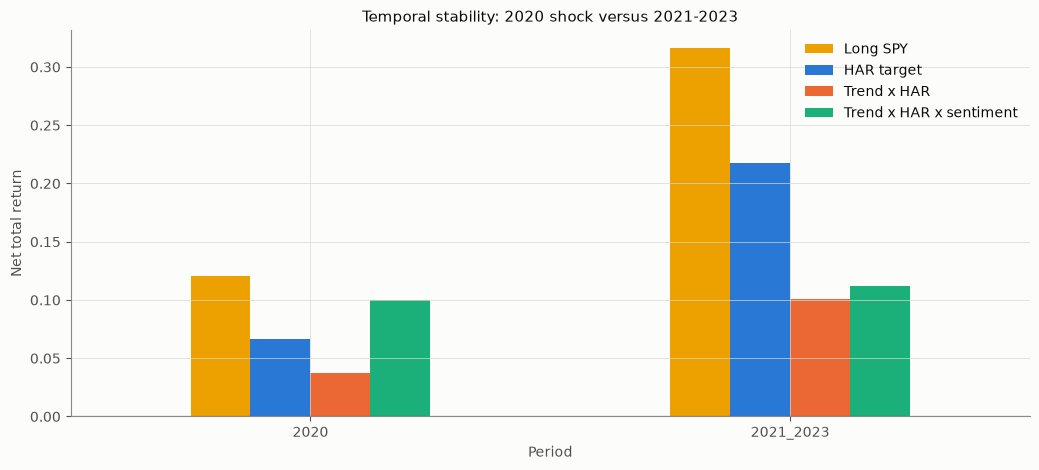

In [13]:
yearly_plot = temporal.pivot(index="period", columns="arm", values="total_return_net")
yearly_plot = yearly_plot[["long_spy", "control_har_target", "trend_200_har", "trend_200_har_sentiment"]]
yearly_plot = yearly_plot.rename(
    columns={
        "long_spy": "Long SPY",
        "control_har_target": "HAR target",
        "trend_200_har": "Trend x HAR",
        "trend_200_har_sentiment": "Trend x HAR x sentiment",
    }
)
ax = yearly_plot.plot(kind="bar", figsize=(10.5, 4.8), color=[CATEGORICAL[3], CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]])
ax.axhline(0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Period")
ax.set_ylabel("Net total return")
ax.set_title("Temporal stability: 2020 shock versus 2021-2023")
ax.legend(loc="best")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "temporal_returns.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decide

In [14]:
input_audit.to_csv(OUTPUT_DIR / "input_audit.csv", index=False)
trend_audit.to_csv(OUTPUT_DIR / "trend_audit.csv", index=False)
exposure_summary.to_csv(OUTPUT_DIR / "exposure_summary.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
matched_attribution.to_csv(OUTPUT_DIR / "matched_exposure_attribution.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
stability.to_csv(OUTPUT_DIR / "temporal_stability.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
pd.DataFrame([gates]).to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"evaluation_{arm}_daily.parquet", index=False)
matched_daily.to_parquet(OUTPUT_DIR / "evaluation_matched_constant_daily.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

best_sharpe_arm = str(results.sort_values("sharpe_net", ascending=False).iloc[0]["arm"])
manifest = {
    "notebook": "23_fnspid_trend_volatility_sentiment_base",
    "built_for": "base-first SPY trend and volatility policy with a frozen aggregate sentiment modifier",
    "analysis_status": "iterative_evaluation_spec_frozen_before_notebook23_execution_2026-08-05",
    "git_commit_at_execution": git_commit,
    "evaluation_previously_opened": True,
    "design": {
        "asset": "SPY adjusted-open to next adjusted-open",
        "trend_lookback_sessions": TREND_LOOKBACK,
        "trend_formation_lag_sessions": 1,
        "trend_risk_off_exposure": 0.0,
        "har_source": str(HAR_PATH.relative_to(REPO_ROOT)),
        "sentiment_source": str(SENTIMENT_PATH.relative_to(REPO_ROOT)),
        "sentiment_rule": {"entry_z": 1.5, "exit_z": 0.5, "risk_exposure": 0.25},
        "cost_bps_per_side": COST_BPS,
        "cost_grid": list(COST_GRID),
        "bootstrap": {
            "kind": "paired circular block",
            "block_length": BLOCK_LENGTH,
            "replications": REPLICATIONS,
            "seed": SEED,
        },
    },
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "temporal_stability": json.loads(stability.to_json(orient="records")),
    "matched_exposure_attribution": json.loads(matched_attribution.to_json(orient="records"))[0],
    "gates": gates,
    "best_evaluation_sharpe_arm_descriptive_only": best_sharpe_arm,
    "limitations": [
        "the evaluation block was already opened by earlier experiments",
        "the test is iterative and cannot provide fresh confirmatory evidence",
        "the trend lookback is standard and was not swept, but the base was proposed after seeing prior evaluation results",
        "SPY adjusted-open returns omit dividends and cash earns zero",
        "the HAR path is a frozen development-fitted model from Notebook 21",
        "the sentiment overlay reuses Notebook 20 without changing its thresholds",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2, allow_nan=True) + "\n")

base_verdict = "passes" if gates["useful_base_gate"] else "does not pass"
sentiment_verdict = "passes" if gates["useful_sentiment_gate"] else "does not pass"
display(
    Markdown(
        f"""### Decision

The **trend x HAR base {base_verdict}** its predeclared useful-base gate.
Its net Sharpe is **{result_index.loc['trend_200_har', 'sharpe_net']:.3f}** versus
**{result_index.loc['control_har_target', 'sharpe_net']:.3f}** for HAR alone,
with a relative drawdown change of **{base_drawdown_improvement:.1%}**.

The frozen sentiment layer **{sentiment_verdict}** its incremental gate. Its
net Sharpe is **{result_index.loc['trend_200_har_sentiment', 'sharpe_net']:.3f}**
versus **{result_index.loc['trend_200_har', 'sharpe_net']:.3f}** for the independent
base, and its paired net-return difference is
**{10_000 * float(overlay_net_inference['mean']):.3f} bp/day**
(95% block interval **[{10_000 * float(overlay_net_inference['ci_low']):.3f},
{10_000 * float(overlay_net_inference['ci_high']):.3f}]**).

The highest evaluation Sharpe is **{best_sharpe_arm}**, reported descriptively
only. No threshold or lookback is selected from this opened sample.
"""
    )
)

### Decision

The **trend x HAR base does not pass** its predeclared useful-base gate.
Its net Sharpe is **0.431** versus
**0.673** for HAR alone,
with a relative drawdown change of **-11.9%**.

The frozen sentiment layer **does not pass** its incremental gate. Its
net Sharpe is **0.677**
versus **0.431** for the independent
base, and its paired net-return difference is
**0.673 bp/day**
(95% block interval **[-0.321,
1.885]**).

The highest evaluation Sharpe is **trend_200_har_sentiment**, reported descriptively
only. No threshold or lookback is selected from this opened sample.


## Next-step rule

Preserve this result. If the independent base is useful but sentiment is not,
keep the base as a benchmark and test materially different information (for
example validated event novelty or timing), not more thresholds on the same
aggregate score. If the base itself fails, replace the return engine using a
fresh predeclared design rather than tuning the 200-session lookback here.